# grahspj: NGC 5548 Joint SED + SDSS Spectrum Fit

This notebook uses Bandwagon to collect broadband photometry and discover SDSS spectra for NGC 5548, then fits both data sets with one `grahspj` model. The joint model shares the grahspj host and AGN continuum with the spectroscopic likelihood. Broadband photometry keeps grahspj's native SED-scale AGN features, while the SDSS spectral likelihood adds jaxqsofit's detailed tied-line, Fe II, and Balmer components on top of the shared continuum.


In [1]:
from pathlib import Path
import inspect
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np

repo_root = Path.cwd().resolve()
if not (repo_root / "src" / "grahspj").is_dir():
    repo_root = repo_root.parent
bandwagon_root = repo_root.parent / "bandwagon"
jaxqsofit_root = repo_root.parent / "jaxqsofit"
for src_root in (repo_root / "src", bandwagon_root / "src", jaxqsofit_root / "src"):
    if src_root.is_dir() and str(src_root) not in sys.path:
        sys.path.insert(0, str(src_root))

# Notebook kernels keep imported modules alive between edits. Drop grahspj and
# jaxqsofit so rerunning this cell always uses the sibling source trees above.
for module_name in list(sys.modules):
    if module_name == "grahspj" or module_name.startswith("grahspj."):
        del sys.modules[module_name]
    if module_name == "jaxqsofit" or module_name.startswith("jaxqsofit."):
        del sys.modules[module_name]

from bandwagon import matches_to_photometry, query_archival_spectra, xmatch_catalogs
from grahspj import (
    AGNConfig,
    FilterSet,
    FitConfig,
    GRAHSPJ,
    GalaxyConfig,
    InferenceConfig,
    JaxQSOFitConfig,
    LikelihoodConfig,
    Observation,
    PhotometryData,
    SpectroscopyConfig,
    SpectroscopyData,
)

if "backend" not in inspect.signature(SpectroscopyConfig).parameters:
    raise RuntimeError(
        "This notebook imported an older grahspj.SpectroscopyConfig without "
        "the backend option. Restart the kernel or rerun this import cell. "
        f"Imported grahspj from: {sys.modules['grahspj'].__file__}"
    )


Could not import regions, which is required for some of the functionalities of this module.


/Users/colinburke/miniforge3/envs/jaxcpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DSPS_SSP_FN = repo_root.parent / "jaxqsofit" / "tempdata.h5"

coord = SkyCoord(184.0307, -2.2383, unit='deg')

OBJECT_NAME = "SDSSJ121607.37-021418.0"

## Query Bandwagon Photometry


In [3]:
matches = xmatch_catalogs(coord, source_id=[OBJECT_NAME])
for name, table in matches.items():
    print(f"{name}: {len(table)} matched rows")

phot = matches_to_photometry(matches, max_mag_err=1.0)
phot = phot[np.isfinite(phot["flux_mjy"]) & np.isfinite(phot["flux_err_mjy"]) & (phot["flux_err_mjy"] > 0)]
phot.sort("match_distance_arcsec")
phot["catalog", "filter_name", "speclite_name", "flux_mjy", "flux_err_mjy", "psf_fwhm_arcsec", "match_distance_arcsec"]


galex_ais: 1 matched rows
sdss_dr16: 2 matched rows
2mass: 1 matched rows
allwise: 1 matched rows
legacy_dr8_north: 0 matched rows
legacy_dr8_south: 1 matched rows


catalog,filter_name,speclite_name,flux_mjy,flux_err_mjy,psf_fwhm_arcsec,match_distance_arcsec
str9,str9,str11,float64,float64,float64,float64
sdss_dr16,g_sdss,sdss2010-g,0.8234291257686258,0.0030336251523005882,1.44,0.320442
sdss_dr16,i_sdss,sdss2010-i,2.353024026990104,0.0065016457141196205,1.26,0.320442
sdss_dr16,r_sdss,sdss2010-r,1.595241316579017,0.0044078146886538895,1.32,0.320442
sdss_dr16,u_sdss,sdss2010-u,0.2671936764460469,0.003691416975452051,1.53,0.320442
sdss_dr16,z_sdss,sdss2010-z,2.965009861180656,0.019116125609469313,1.29,0.320442
allwise,W1,wise2010-W1,2.12969162641557,0.05492251904185422,6.08,0.336625
allwise,W2,wise2010-W2,1.8272183629081464,0.05217083862191937,6.84,0.336625
allwise,W3,wise2010-W3,5.075781820771904,0.33659766871723795,7.36,0.336625
allwise,W4,wise2010-W4,14.506482439538885,2.4183344232632495,11.99,0.336625


## Query Bandwagon SDSS Spectra


In [4]:
spectra = query_archival_spectra(
    coord,
    source_id=[OBJECT_NAME],
    providers=("sdss",),
    radius_arcsec=5.0,
)
spectra.sort("redshift")
spectra[
    "provider",
    "release",
    "obs_id",
    "redshift",
    "quality",
    "sdss_plate",
    "sdss_mjd",
    "sdss_fiberid",
]


provider,release,obs_id,redshift,quality,sdss_plate,sdss_mjd,sdss_fiberid
str4,str4,str13,float64,str1,str3,str5,str3
sdss,dr17,332-52367-639,0.1006098,,332,52367,639


In [5]:
sdss_rows = spectra[spectra["provider"] == "sdss"]
if len(sdss_rows) == 0:
    raise RuntimeError("No SDSS spectrum was found for NGC 5548.")

# Prefer rows with clean SDSS zwarning when available.
quality = np.asarray([str(q).strip() for q in sdss_rows["quality"]])
clean = np.flatnonzero((quality == "0") | (quality == ""))
row = sdss_rows[int(clean[0])] if clean.size else sdss_rows[0]

plate = int(row["sdss_plate"])
mjd = int(row["sdss_mjd"])
fiberid = int(row["sdss_fiberid"])
redshift = float(row["redshift"])
print(f"Using SDSS spectrum plate={plate}, mjd={mjd}, fiber={fiberid}, z={redshift:.5f}")

sdss_hdul = SDSS.get_spectra(plate=plate, mjd=mjd, fiberID=fiberid)[0]
sdss_data = sdss_hdul[1].data
wave_obs = 10.0 ** np.asarray(sdss_data["loglam"], dtype=float)
flux_1e17 = np.asarray(sdss_data["flux"], dtype=float)
ivar = np.asarray(sdss_data["ivar"], dtype=float)
err_1e17 = np.where(ivar > 0.0, 1.0 / np.sqrt(ivar), np.nan)


Using SDSS spectrum plate=332, mjd=52367, fiber=639, z=0.10061


/var/folders/kx/qz91z8390zqfjrd9v6mt61w00000gn/T/ipykernel_4428/3764249350.py:21: RuntimeWarning: divide by zero encountered in divide
  err_1e17 = np.where(ivar > 0.0, 1.0 / np.sqrt(ivar), np.nan)


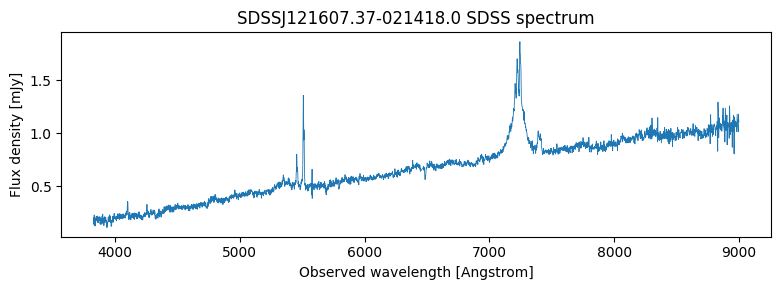

In [6]:
C_ANG_PER_S = 2.99792458e18

def flambda_1e17_to_mjy(wave_angstrom, flux_1e17):
    f_lambda_cgs = np.asarray(flux_1e17, dtype=float) * 1.0e-17
    f_nu_cgs = f_lambda_cgs * np.asarray(wave_angstrom, dtype=float) ** 2 / C_ANG_PER_S
    return f_nu_cgs / 1.0e-26


spec_flux_mjy = flambda_1e17_to_mjy(wave_obs, flux_1e17)
spec_err_mjy = flambda_1e17_to_mjy(wave_obs, err_1e17)
spec_mask = (
    np.isfinite(wave_obs)
    & np.isfinite(spec_flux_mjy)
    & np.isfinite(spec_err_mjy)
    & (spec_err_mjy > 0.0)
    & (wave_obs > 3600.0)
    & (wave_obs < 9000.0)
)

plt.figure(figsize=(8, 3))
plt.plot(wave_obs[spec_mask], spec_flux_mjy[spec_mask], lw=0.6)
plt.xlabel("Observed wavelength [Angstrom]")
plt.ylabel("Flux density [mJy]")
plt.title(f"{OBJECT_NAME} SDSS spectrum")
plt.tight_layout()


In [7]:
spec_wave_native = wave_obs[spec_mask]
spec_flux_native = spec_flux_mjy[spec_mask]
spec_err_native = spec_err_mjy[spec_mask]

print(f"Using {spec_wave_native.size:,} native SDSS spectral pixels")



Using 3,690 native SDSS spectral pixels


## Build A Joint Photometry + Spectrum Config


In [8]:
filter_names = [str(name) for name in phot["filter_name"]]
speclite_names = {str(row["filter_name"]): str(row["speclite_name"]) for row in phot}

cfg = FitConfig(
    observation=Observation(
        object_id="NGC5548_joint",
        redshift=redshift,
        fit_redshift=False,
        ra=float(coord.ra.deg),
        dec=float(coord.dec.deg),
        apply_mw_deredden=False,
    ),
    photometry=PhotometryData(
        filter_names=filter_names,
        fluxes=[float(x) for x in phot["flux_mjy"]],
        errors=[float(x) for x in phot["flux_err_mjy"]],
        is_upper_limit=[False] * len(phot),
        psf_fwhm_arcsec=[float(x) if np.isfinite(x) else None for x in phot["psf_fwhm_arcsec"]],
    ),
    filters=FilterSet(speclite_names=speclite_names, use_grahsp_database=False),
    spectroscopy=SpectroscopyData(
        wave_obs=spec_wave_native.tolist(),
        fluxes=spec_flux_native.tolist(),
        errors=spec_err_native.tolist(),
        mask=[True] * len(spec_wave_native),
        instrument="SDSS",
        aperture_diameter_arcsec=3.0,
    ),
    spectroscopy_config=SpectroscopyConfig(
        enabled=True,
        backend="jaxqsofit",
        fit_scale=True,
        scale_prior_sigma_dex=0.4,
        systematics_width=0.08,
        student_t_df=5.0,
        # These jaxqsofit switches affect only the spectroscopic likelihood.
        # Photometric fluxes still use grahspj native SED-scale AGN features.
        jaxqsofit=JaxQSOFitConfig(
            use_spectral_lines=True,
            use_tied_lines=True,
            use_spectral_smart_priors=True,
            use_spectral_feii=True,
            use_spectral_balmer_continuum=True,
            line_flux_scale_mjy=0.1,
        ),
    ),
    galaxy=GalaxyConfig(
        dsps_ssp_fn=str(DSPS_SSP_FN),
        n_wave=2048,
        rest_wave_min=100.0,
        rest_wave_max=3.0e6,
        fit_host_kinematics=True,
    ),
    agn=AGNConfig(
        agn_type=1,
        line_width_kms_default=3000.0,
        lines_strength_default=1.0,
        feii_strength_default=1.0,
        fit_balmer_continuum=True,
        balmer_continuum_default=0.1,
    ),
    likelihood=LikelihoodConfig(
        use_host_capture_model=True,
        systematics_width=0.08,
        fit_intrinsic_scatter=True,
    ),
    inference=InferenceConfig(map_steps=600, learning_rate=5.0e-3, seed=3),
)
cfg.validate()
cfg


FitConfig(observation=Observation(object_id='NGC5548_joint', redshift=0.1006098, fit_redshift=False, redshift_err=0.0, ra=184.0307, dec=-2.2383, apply_mw_deredden=False), photometry=PhotometryData(filter_names=['g_sdss', 'i_sdss', 'r_sdss', 'u_sdss', 'z_sdss', 'W1', 'W2', 'W3', 'W4', 'H_2mass', 'J_2mass', 'Ks_2mass', 'FUV_galex', 'NUV_galex'], fluxes=[0.8234291257686258, 2.353024026990104, 1.595241316579017, 0.2671936764460469, 2.965009861180656, 2.12969162641557, 1.8272183629081464, 5.075781820771904, 14.506482439538885, 2.002164844859573, 1.6675859662246768, 2.2569950082481194, 0.023732641183329954, 0.05139801584030668], errors=[0.0030336251523005882, 0.0065016457141196205, 0.0044078146886538895, 0.003691416975452051, 0.019116125609469313, 0.05492251904185422, 0.05217083862191937, 0.33659766871723795, 2.4183344232632495, 0.17518588497034165, 0.11980047038975684, 0.14759261976336402, 0.004644946323806763, 0.004596648032305907], is_upper_limit=[False, False, False, False, False, False,

## Fit

The first run below uses MAP/SVI with staged continuum-first initialization, which is now the default for `fit_method="optax"`. Increase `optax_steps` or switch to `fit_method="optax+nuts"` once the model and data choices look sensible.


In [9]:
fitter = GRAHSPJ(cfg)
result = fitter.fit(
    fit_method="optax+nuts",
    optax_steps=cfg.inference.map_steps,
    optax_lr=cfg.inference.learning_rate,
    progress_bar=True,
    plot_fig=False,
    save_fig=False,
)
result["summary"]


sample: 100%|██████████| 400/400 [13:09<00:00,  1.97s/it, 255 steps of size 1.49e-02. acc. prob=0.94]


{'absolute_flux_scale_logprior_median': -0.2523966355465701,
 'agn_variability_nev_median': 0.028165423095661182,
 'balmer_norm_median': 0.0992662389125581,
 'balmer_tau_median': 0.9711281492759207,
 'balmer_vel_median': 2868.603496314676,
 'cool_lam_median': 16.55635585348594,
 'cool_width_median': 0.3971040060102381,
 'dust_alpha_median': 2.097213760346645,
 'dust_alpha_fit_median': 2.097213760346645,
 'ebv_agn_median': 0.15230779932086894,
 'ebv_gal_median': 0.11604860167497491,
 'fcov_median': 0.050578832941442886,
 'feii_norm_median': 1.176483896027853,
 'formed_stellar_mass_median': 63697685813.26502,
 'fracAGN_5100_fit_median': 0.6805081337205492,
 'gal_lgmet_median': -1.3469923664173302,
 'gal_lgmet_fit_median': -1.3469923664173302,
 'gal_lgmet_scatter_median': 0.09911520203477833,
 'gal_lgmet_scatter_fit_median': 0.09911520203477833,
 'gal_sigma_kms_median': 144.10920943764688,
 'gal_v_kms_median': -48.983790287316644,
 'host_capture_fraction_fluxes_median': [0.961353894651234

In [10]:
pred = fitter.predict()
print(f"Joint backend: {cfg.spectroscopy_config.backend}")
print("Spectra in model context:", len(fitter.context.spec_instruments))
print("Spectrum instruments:", fitter.context.spec_instruments)
print("Predictive spectral sites:", sorted(k for k in pred if k.startswith("jqf_") or k.startswith("pred_spectrum")))


Joint backend: jaxqsofit
Spectra in model context: 1
Spectrum instruments: ('SDSS',)
Predictive spectral sites: ['jqf_balmer_model', 'jqf_continuum_model', 'jqf_feii_model', 'jqf_line_amp_per_component', 'jqf_line_model', 'jqf_line_model_broad', 'jqf_line_model_narrow', 'jqf_line_mu_per_component', 'jqf_line_narrow_amp_scale', 'jqf_line_narrow_fwhm_kms', 'jqf_line_sig_per_component', 'jqf_total_model', 'pred_spectrum_fluxes']


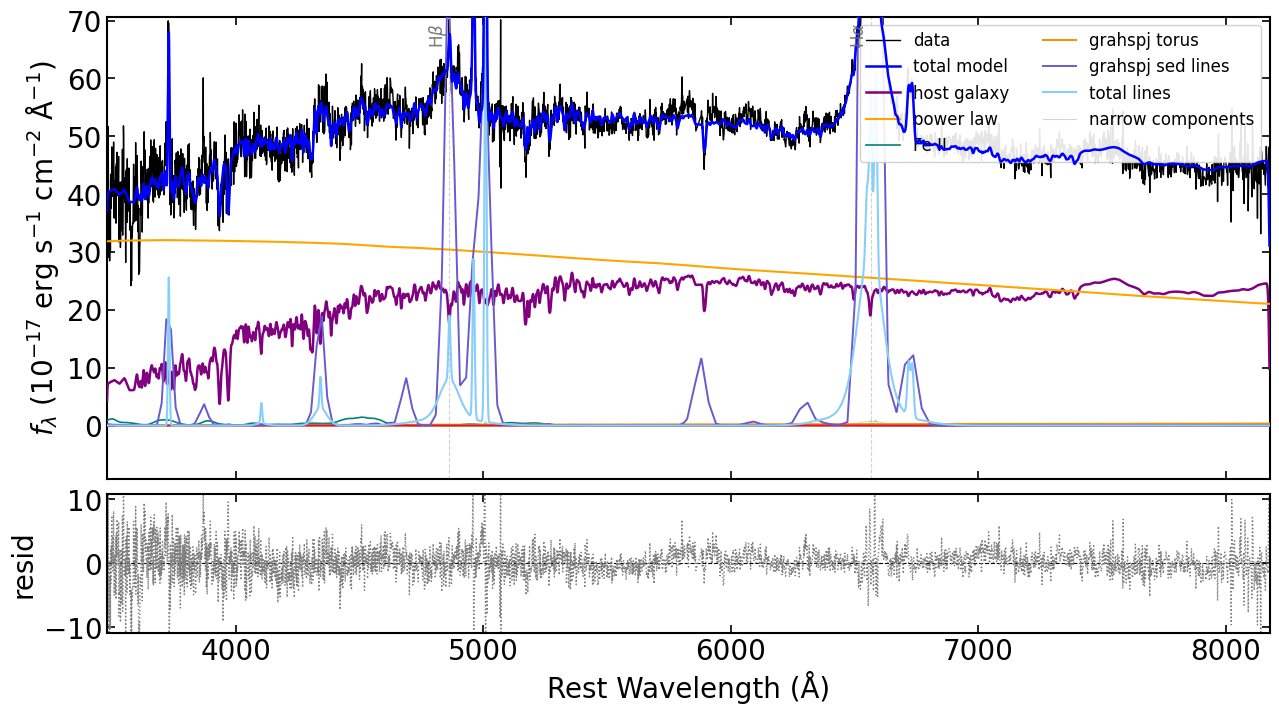

In [11]:
fig = fitter.plot_jaxqsofit_spectrum(
    spectrum_index=0,
    show_plot=True,
    plot_residual=True,
    plot_legend=True,
)


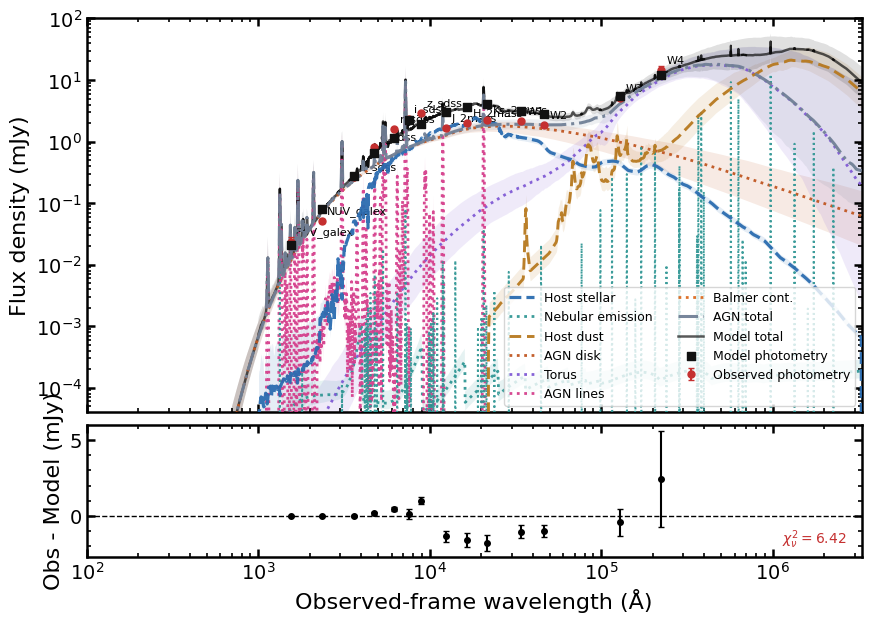

In [14]:
fitter.plot_sed()